# Customer Segmentation — Unsupervised Learning Pipeline


## 0. Environment Setup
This section loads all the required libraries for data handling, visualisation, and machine learning.  
Random seeds are set to keep the results consistent every time the notebook runs.

In [71]:
# Import required libraries
import pandas as pd          # data handling
import numpy as np           # numerical operations
import matplotlib.pyplot as plt
import seaborn as sns        # visualisation tools

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

# Set consistent plotting style
plt.style.use("seaborn-v0_8")
sns.set_palette("husl")

# Set random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)

print("0. Environment setup complete.")

0. Environment setup complete.


## 1. Data Loading and Initial Inspection
This section loads the Customer Shopping Trends dataset and performs a quick structural check.  
This helps confirm the number of rows, columns, and data types before starting the exploratory analysis.

In [72]:
# 1.1 Load dataset shopping_trends
print("1.1 LOADING DATASET")
print("-" * 60)

df = pd.read_csv("shopping_trends.csv")
print(f"Dataset loaded successfully. Shape: {df.shape}\n")

1.1 LOADING DATASET
------------------------------------------------------------
Dataset loaded successfully. Shape: (3900, 19)



In [74]:
# 1.2 Preview the first few rows
print("1.2 PREVIEW OF DATASET")
print("-" * 60)

display(df.head())

1.2 PREVIEW OF DATASET
------------------------------------------------------------


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually


### Figure 1 (Appendix A1) — First five rows of the customer shopping dataset
This preview shows the dataset’s demographic, behavioural and transactional fields. All columns are complete with no missing values, confirming the dataset is fully usable without imputation. Early inspection suggests customers display broadly similar attributes, without obvious segment separation.

In [75]:
# 1.3 Dataset info
print("1.3 DATASET INFO")
print("-" * 60)

df.info()


1.3 DATASET INFO
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null 

### Figure 2 (Appendix A2) — Column overview and dataset information
This summary lists the 19 features and their data types, confirming that the dataset contains a mix of categorical and numerical variables. The presence of many nominal categories suggests that encoding choices may influence clustering performance.

In [76]:
# 1.4 Summary statistics
print("1.4 SUMMARY STATISTICS")
print("-" * 60)

display(df.describe(include='all'))


1.4 SUMMARY STATISTICS
------------------------------------------------------------


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Credit Card,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,696,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.749949,NaN,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716223,NaN,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.700000,NaN,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [77]:
# 1.5 Missing values check
print("1.5 MISSING VALUES")
print("-" * 60)

print(df.isnull().sum())


1.5 MISSING VALUES
------------------------------------------------------------
Customer ID                 0
Age                         0
Gender                      0
Item Purchased              0
Category                    0
Purchase Amount (USD)       0
Location                    0
Size                        0
Color                       0
Season                      0
Review Rating               0
Subscription Status         0
Payment Method              0
Shipping Type               0
Discount Applied            0
Promo Code Used             0
Previous Purchases          0
Preferred Payment Method    0
Frequency of Purchases      0
dtype: int64


In [78]:
# 1.6 Column names
print("1.6 COLUMN NAMES")
print("-" * 60)

print(df.columns.tolist())


1.6 COLUMN NAMES
------------------------------------------------------------
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Preferred Payment Method', 'Frequency of Purchases']


## 2. Exploratory Data Analysis (EDA)
This section examines the main features in the dataset and highlights patterns and relationships that are relevant for clustering.

### 2.1 Overview of Variables
A quick review of the key features to understand what each column represents and how it may influence clustering.

In [79]:
# 2.1 Column Overview

print("\n2.1 COLUMN OVERVIEW")
print("-" * 60)
print("Columns in the dataset:")
print(df.columns.tolist())


2.1 COLUMN OVERVIEW
------------------------------------------------------------
Columns in the dataset:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Payment Method', 'Shipping Type', 'Discount Applied', 'Promo Code Used', 'Previous Purchases', 'Preferred Payment Method', 'Frequency of Purchases']


### 2.2 Numeric Feature Distributions
Here I look at the distributions for numerical features like Age, Purchase Amount, and Review Rating.


2.2 NUMERIC FEATURE DISTRIBUTIONS
------------------------------------------------------------


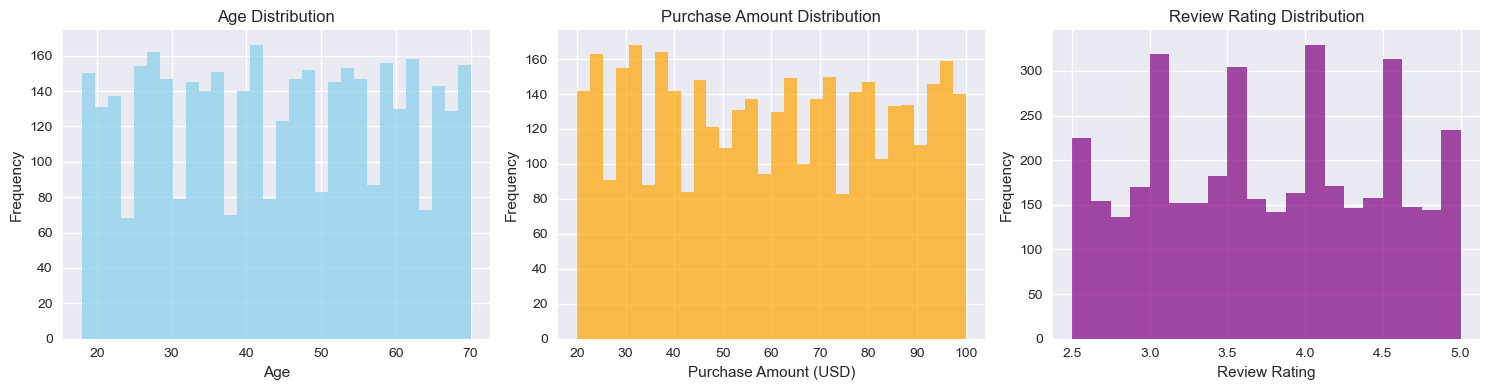

In [80]:
# 2.2 Numeric Feature Distributions

print("\n2.2 NUMERIC FEATURE DISTRIBUTIONS")
print("-" * 60)

plt.figure(figsize=(15, 4))

# Age Distribution
plt.subplot(1, 3, 1)
df["Age"].hist(bins=30, color="skyblue", alpha=0.7)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Purchase Amount Distribution
plt.subplot(1, 3, 2)
df["Purchase Amount (USD)"].hist(bins=30, color="orange", alpha=0.7)
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Frequency")

# Review Rating Distribution
plt.subplot(1, 3, 3)
df["Review Rating"].hist(bins=20, color="purple", alpha=0.7)
plt.title("Review Rating Distribution")
plt.xlabel("Review Rating")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


### Figure 3a (Appendix A3) — Distributions of key numerical variables
This set of histograms shows the distributions for Age, Purchase Amount (USD) and Review Rating. All three variables display broadly even or mildly centralised trends, with no clear multimodal structure. These patterns suggest that strong numerical separation between customer groups is unlikely.

### 2.3 Categorical Feature Distributions
This part examines how frequently different categories appear, such as Gender, Season and Category.


2.3a CATEGORICAL FEATURE DISTRIBUTIONS (PART 1)
------------------------------------------------------------


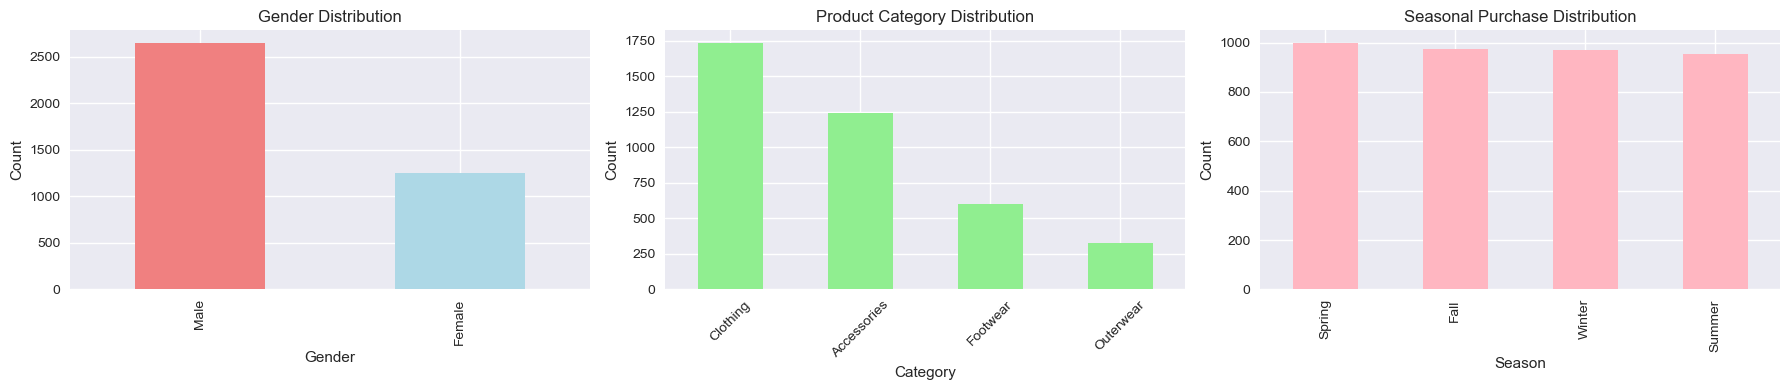

In [81]:
# 2.3a Categorical Feature Distributions (Part 1)

print("\n2.3a CATEGORICAL FEATURE DISTRIBUTIONS (PART 1)")
print("-" * 60)

plt.figure(figsize=(18, 4))

# Gender Distribution
plt.subplot(1, 3, 1)
df["Gender"].value_counts().plot(kind="bar", color=["lightcoral", "lightblue"])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

# Category Distribution
plt.subplot(1, 3, 2)
df["Category"].value_counts().plot(kind="bar", color="lightgreen")
plt.title("Product Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Season Distribution
plt.subplot(1, 3, 3)
df["Season"].value_counts().plot(kind="bar", color="lightpink")
plt.title("Seasonal Purchase Distribution")
plt.xlabel("Season")
plt.ylabel("Count")

plt.tight_layout()
plt.show()



### Figure 3b (Appendix A3) — Categorical distributions (Part 1)
These bar plots display the frequency of Gender, Category and Season. The relatively even spread across categories indicates that customers do not fall naturally into dominant behavioural groups, limiting the potential for strong segmentation.


2.3b CATEGORICAL FEATURE DISTRIBUTIONS (PART 2)
------------------------------------------------------------


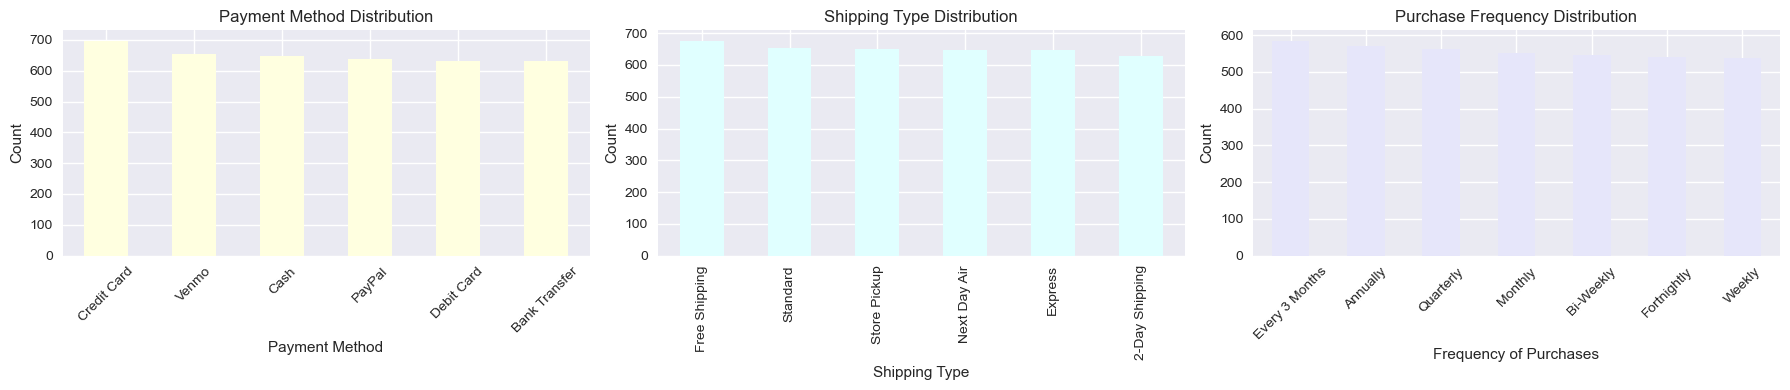

In [82]:
# 2.3b Categorical Feature Distributions (Part 2)

print("\n2.3b CATEGORICAL FEATURE DISTRIBUTIONS (PART 2)")
print("-" * 60)

plt.figure(figsize=(18, 4))

# Payment Method Distribution
plt.subplot(1, 3, 1)
df["Payment Method"].value_counts().plot(kind="bar", color="lightyellow")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=45)

# Shipping Type Distribution
plt.subplot(1, 3, 2)
df["Shipping Type"].value_counts().plot(kind="bar", color="lightcyan")
plt.title("Shipping Type Distribution")
plt.xlabel("Shipping Type")
plt.ylabel("Count")

# Frequency of Purchases Distribution
plt.subplot(1, 3, 3)
df["Frequency of Purchases"].value_counts().plot(kind="bar", color="lavender")
plt.title("Purchase Frequency Distribution")
plt.xlabel("Frequency of Purchases")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Figure 3b (Appendix A3) — Categorical distributions (Part 2)
This second set of categorical plots shows the distributions for Payment Method, Shipping Type and Frequency of Purchases. The balanced representation across these variables reinforces the earlier observation that customers behave in broadly similar ways, making cluster formation more challenging.

### 2.4 Correlation Heatmap
A simple correlation matrix shows how the numeric features relate to each other.


2.4 NUMERICAL FEATURES CORRELATION
------------------------------------------------------------
Numeric columns included in correlation matrix: ['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']


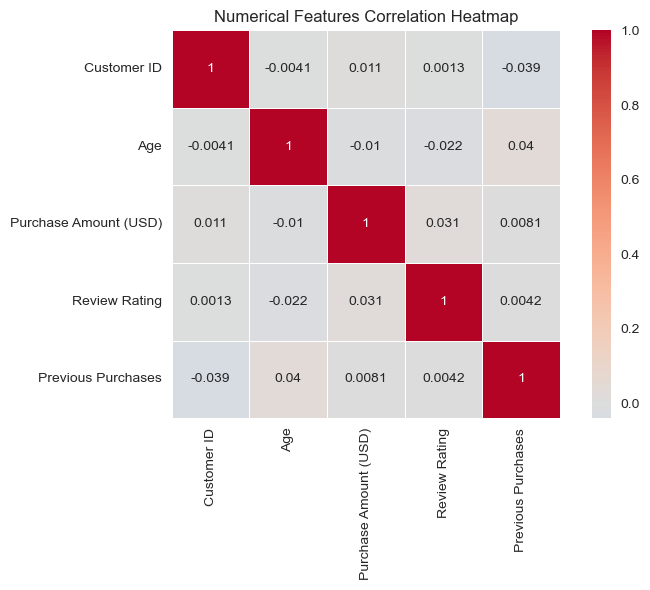

In [84]:
# 2.4 Numerical Features Correlation

print("\n2.4 NUMERICAL FEATURES CORRELATION")
print("-" * 60)

numerical_features = df.select_dtypes(include=[np.number]).columns
print(f"Numeric columns included in correlation matrix: {list(numerical_features)}")

if len(numerical_features) > 1:
    correlation_matrix = df[numerical_features].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        correlation_matrix,
        annot=True,
        cmap="coolwarm",
        center=0,
        square=True,
        linewidths=0.5,
    )
    plt.title("Numerical Features Correlation Heatmap")
    plt.tight_layout()
    plt.show()

### Figure 4 (Appendix A4) — Correlation heatmap of numerical features
Correlations between numerical variables are extremely weak, with no pairs showing strong linear relationships. This suggests that numerical features do not naturally form clusters, which aligns with the weak cluster separation observed later in the analysis.

### 2.5 Key EDA Notes
A short summary of the main patterns observed during EDA.

In [85]:
# 2.5 Key EDA Insights

print("\n2.5 KEY EDA INSIGHTS")
print("-" * 60)
print(f"- Dataset contains {len(df)} customer records.")
print(f"- Gender distribution: {df['Gender'].value_counts().to_dict()}")
print(f"- Age range: {df['Age'].min()} to {df['Age'].max()} years.")
print(
    f"- Purchase amount range: ${df['Purchase Amount (USD)'].min()} "
    f"to ${df['Purchase Amount (USD)'].max()}."
)
print(f"- Most popular category: {df['Category'].value_counts().index[0]}.")


2.5 KEY EDA INSIGHTS
------------------------------------------------------------
- Dataset contains 3900 customer records.
- Gender distribution: {'Male': 2652, 'Female': 1248}
- Age range: 18 to 70 years.
- Purchase amount range: $20 to $100.
- Most popular category: Clothing.


### 2.5 Key EDA Notes
- Age and purchase amounts show wide variation, which is useful for clustering.
- Categorical features such as Season and Category have clear dominant groups.
- Correlation levels are generally low, meaning each numeric feature contributes unique information.


## 3. Data Preprocessing for Clustering
This section prepares the dataset for clustering by selecting relevant features, encoding categorical variables, and scaling the inputs.

In [86]:
# 3.1 Data Preprocessing for Clustering

print("\n3. DATA PREPROCESSING FOR CLUSTERING")
print("-" * 60)

# 3.1 Feature Selection

print("\n3.1 FEATURE SELECTION")
print("-" * 60)

# Create a copy for preprocessing
df_processed = df.copy()

# Select relevant features for clustering
clustering_features = [
    "Age", "Purchase Amount (USD)", "Review Rating",
    "Category", "Season", "Payment Method", "Shipping Type",
    "Frequency of Purchases", "Gender"
]

print("Selected features for clustering:")
print(clustering_features)

# 3.2 Encoding Categorical Variables

print("\n3.2 ENCODING CATEGORICAL VARIABLES")
print("-" * 60)

label_encoders = {}
categorical_columns = [
    "Category", "Season", "Payment Method", "Shipping Type",
    "Frequency of Purchases", "Gender"
]

for col in categorical_columns:
    if col in df_processed.columns:
        le = LabelEncoder()
        df_processed[col + "_encoded"] = le.fit_transform(df_processed[col])
        label_encoders[col] = le
        print(f"{col} encoded with {len(le.classes_)} categories.")

# Create feature set for clustering
feature_columns = [
    "Age",
    "Purchase Amount (USD)",
    "Review Rating"
] + [
    col + "_encoded" for col in categorical_columns
    if col + "_encoded" in df_processed.columns
]

X = df_processed[feature_columns]

print("\nFinal feature set created.")
print(f"Feature set shape: {X.shape}")
print(f"Features used: {feature_columns}")

# 3.3 Scaling Features

print("\n3.3 SCALING FEATURES")
print("-" * 60)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed successfully.")


3. DATA PREPROCESSING FOR CLUSTERING
------------------------------------------------------------

3.1 FEATURE SELECTION
------------------------------------------------------------
Selected features for clustering:
['Age', 'Purchase Amount (USD)', 'Review Rating', 'Category', 'Season', 'Payment Method', 'Shipping Type', 'Frequency of Purchases', 'Gender']

3.2 ENCODING CATEGORICAL VARIABLES
------------------------------------------------------------
Category encoded with 4 categories.
Season encoded with 4 categories.
Payment Method encoded with 6 categories.
Shipping Type encoded with 6 categories.
Frequency of Purchases encoded with 7 categories.
Gender encoded with 2 categories.

Final feature set created.
Feature set shape: (3900, 9)
Features used: ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Category_encoded', 'Season_encoded', 'Payment Method_encoded', 'Shipping Type_encoded', 'Frequency of Purchases_encoded', 'Gender_encoded']

3.3 SCALING FEATURES
---------------------

## 4. Determining the Optimal Number of Clusters (K-Means)
This section evaluates different values of *k* using the elbow method and silhouette scores to identify the most suitable number of clusters for K-Means.

In [87]:
# 4.1 Elbow and Silhouette Analysis

print("\n4.1 ELBOW AND SILHOUETTE ANALYSIS")
print("-" * 60)

wcss = []                 # Within-cluster sum of squares
silhouette_scores = []
k_range = range(2, 11)

print("Evaluating cluster quality for k = 2 to 10...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

print("Calculation completed.")



4.1 ELBOW AND SILHOUETTE ANALYSIS
------------------------------------------------------------
Evaluating cluster quality for k = 2 to 10...
Calculation completed.



4.2 VISUALISING ELBOW CURVE AND SILHOUETTE SCORES
------------------------------------------------------------


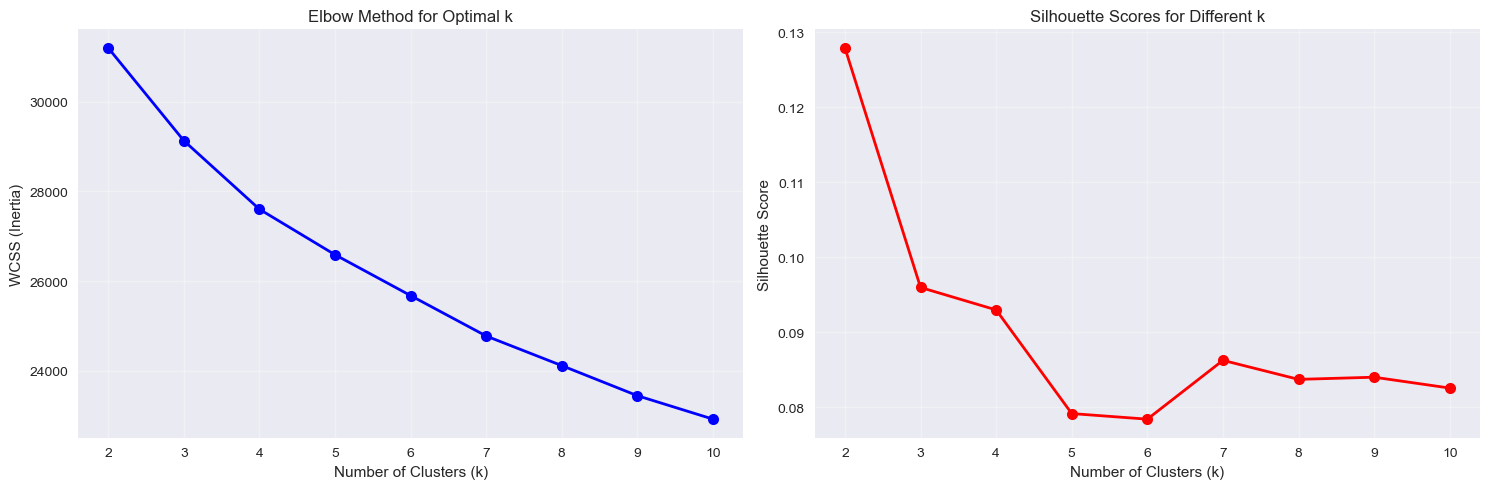

In [88]:
# 4.2 Visualising Elbow Curve and Silhouette Scores

print("\n4.2 VISUALISING ELBOW CURVE AND SILHOUETTE SCORES")
print("-" * 60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow curve
ax1.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True, alpha=0.3)

# Silhouette scores
ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores for Different k')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Figure 5 (Appendix B1) — Elbow method for determining the number of clusters
The WCSS curve shows a smooth decline without a distinct inflection point, indicating that no particular value of k produces strongly compact clusters. This behaviour suggests that the dataset lacks clear natural segmentation based on within-cluster variance.

### Figure 6 (Appendix B2) — Silhouette scores for different k values
Silhouette scores remain low across all tested values of k, with the highest value at k = 2. These consistently weak values confirm poor separation between potential clusters and indicate that strong behavioural groupings are unlikely to exist in the dataset.

In [89]:
# 4.3 Selecting The Optimal Number of Clusters

print("\n4.3 SELECTING THE OPTIMAL NUMBER OF CLUSTERS")
print("-" * 60)

optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"Optimal number of clusters based on silhouette score: {optimal_k}")



4.3 SELECTING THE OPTIMAL NUMBER OF CLUSTERS
------------------------------------------------------------
Optimal number of clusters based on silhouette score: 2


## 5. Clustering Implementation (K-Means and DBSCAN)
This section applies K-Means and DBSCAN to group customers based on their shopping behaviour.

In [90]:
# 5.1 K-Means Clustering

print("\n5. CLUSTERING IMPLEMENTATION")
print("-" * 60)

print("\n5.1 K-MEANS CLUSTERING")
print("-" * 60)
print(f"Fitting K-Means model with k = {optimal_k}...")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed.")
print(f"Unique K-Means clusters: {np.unique(kmeans_labels)}")



5. CLUSTERING IMPLEMENTATION
------------------------------------------------------------

5.1 K-MEANS CLUSTERING
------------------------------------------------------------
Fitting K-Means model with k = 2...
K-Means clustering completed.
Unique K-Means clusters: [0 1]


In [91]:
# 5.2 DBSCAN Clustering

print("\n5.2 DBSCAN CLUSTERING")
print("-" * 60)
print("Fitting DBSCAN with initial parameters (eps=0.5, min_samples=5)...")

dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

unique_dbscan_labels = np.unique(dbscan_labels)
print(f"Initial DBSCAN clusters (including noise): {unique_dbscan_labels}")

# If DBSCAN finds only noise or very few clusters, adjust parameters
if len(unique_dbscan_labels) <= 2:
    print("DBSCAN found limited structure. Adjusting parameters (eps=0.8, min_samples=10)...")
    dbscan = DBSCAN(eps=0.8, min_samples=10)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    unique_dbscan_labels = np.unique(dbscan_labels)
    print(f"Adjusted DBSCAN clusters (including noise): {unique_dbscan_labels}")
else:
    print("DBSCAN produced a reasonable number of clusters with the initial parameters.")



5.2 DBSCAN CLUSTERING
------------------------------------------------------------
Fitting DBSCAN with initial parameters (eps=0.5, min_samples=5)...
Initial DBSCAN clusters (including noise): [-1]
DBSCAN found limited structure. Adjusting parameters (eps=0.8, min_samples=10)...
Adjusted DBSCAN clusters (including noise): [-1]


In [92]:
# 5.3 Cluster Label Summary and Assignment

print("\n5.3 CLUSTER LABEL SUMMARY AND ASSIGNMENT")
print("-" * 60)

print(f"K-Means clusters found: {len(np.unique(kmeans_labels))}")
print(f"DBSCAN clusters found (including noise): {len(np.unique(dbscan_labels))}")

# Add cluster labels to the processed dataframe
df_processed["cluster_kmeans"] = kmeans_labels
df_processed["cluster_dbscan"] = dbscan_labels

print("\nCluster labels added to df_processed:")
print(df_processed[["cluster_kmeans", "cluster_dbscan"]].head())



5.3 CLUSTER LABEL SUMMARY AND ASSIGNMENT
------------------------------------------------------------
K-Means clusters found: 2
DBSCAN clusters found (including noise): 1

Cluster labels added to df_processed:
   cluster_kmeans  cluster_dbscan
0               1              -1
1               1              -1
2               1              -1
3               1              -1
4               1              -1


## 6. Cluster Evaluation and Visualisation
This section evaluates the clusters produced by K-Means and DBSCAN using silhouette, Calinski–Harabasz, and Davies–Bouldin scores.

In [93]:
# 6.1 Cluster Evaluation Metrics

print("\n6.1 CLUSTER EVALUATION METRICS")
print("-" * 60)

clustering_results = {}

# ----- K-Means Evaluation -----
if len(np.unique(kmeans_labels)) > 1:
    kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
    kmeans_calinski = calinski_harabasz_score(X_scaled, kmeans_labels)
    kmeans_davies = davies_bouldin_score(X_scaled, kmeans_labels)
else:
    kmeans_silhouette = kmeans_calinski = kmeans_davies = 0

# ----- DBSCAN Evaluation -----
dbscan_unique = np.unique(dbscan_labels[dbscan_labels != -1])  # ignore noise

if len(dbscan_unique) > 1:
    dbscan_silhouette = silhouette_score(X_scaled, dbscan_labels)
    dbscan_calinski = calinski_harabasz_score(X_scaled, dbscan_labels)
    dbscan_davies = davies_bouldin_score(X_scaled, dbscan_labels)
else:
    dbscan_silhouette = dbscan_calinski = dbscan_davies = 0

# Store results in dictionary
clustering_results = {
    "K-Means": {
        "labels": kmeans_labels,
        "silhouette": kmeans_silhouette,
        "calinski": kmeans_calinski,
        "davies": kmeans_davies,
        "n_clusters": len(np.unique(kmeans_labels))
    },
    "DBSCAN": {
        "labels": dbscan_labels,
        "silhouette": dbscan_silhouette,
        "calinski": dbscan_calinski,
        "davies": dbscan_davies,
        "n_clusters": len(dbscan_unique)
    }
}

# Display metrics table
print("\nClustering Performance Metrics:\n")
metrics_df = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Number of Clusters": [
        clustering_results["K-Means"]["n_clusters"],
        clustering_results["DBSCAN"]["n_clusters"]
    ],
    "Silhouette Score": [
        clustering_results["K-Means"]["silhouette"],
        clustering_results["DBSCAN"]["silhouette"]
    ],
    "Calinski-Harabasz Score": [
        clustering_results["K-Means"]["calinski"],
        clustering_results["DBSCAN"]["calinski"]
    ],
    "Davies-Bouldin Score": [
        clustering_results["K-Means"]["davies"],
        clustering_results["DBSCAN"]["davies"]
    ]
})

print(metrics_df.round(4))



6.1 CLUSTER EVALUATION METRICS
------------------------------------------------------------

Clustering Performance Metrics:

  Algorithm  Number of Clusters  Silhouette Score  Calinski-Harabasz Score  \
0   K-Means                   2            0.1279                 487.8258   
1    DBSCAN                   0            0.0000                   0.0000   

   Davies-Bouldin Score  
0                2.5977  
1                0.0000  


### Figure 9 (Appendix C1) — Clustering evaluation metrics for K-Means and DBSCAN
The metrics table shows that K-Means produces weakly defined clusters with low Silhouette, moderate CH, and high DB values. DBSCAN metrics indicate no valid multi-cluster structure. These results collectively demonstrate that neither algorithm provides strong or actionable segmentation.


6.2 PCA CLUSTER VISUALISATION
------------------------------------------------------------


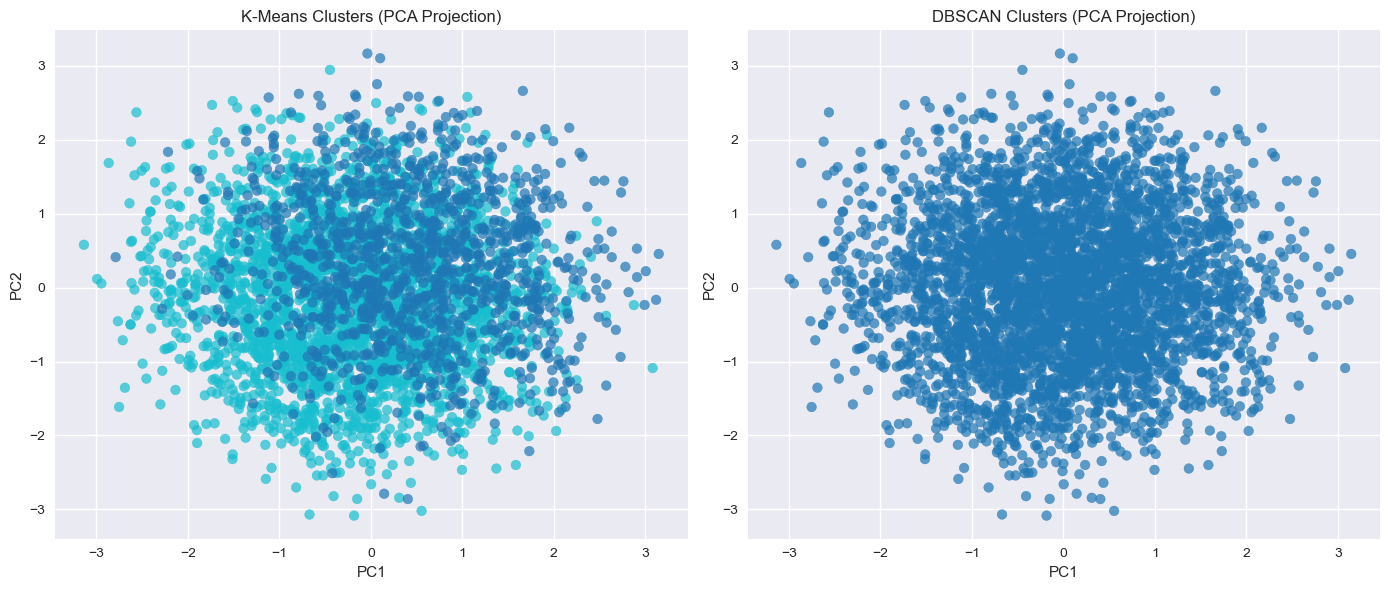

In [94]:
# 6.2 PCA Cluster Visualisation

print("\n6.2 PCA CLUSTER VISUALISATION")
print("-" * 60)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

# K-Means Plot
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap="tab10", alpha=0.7)
plt.title("K-Means Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")

# DBSCAN Plot
plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap="tab10", alpha=0.7)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.tight_layout()
plt.show()


### Figure 7 (Appendix B3) — PCA visualisation of K-Means and DBSCAN clusters
The PCA projections show substantial overlap between K-Means clusters and a single dense group produced by DBSCAN. The absence of visually distinct shapes reinforces the idea that the features do not provide meaningful separation between different types of customers.

In [95]:
# 6.3 Summary of Model Performance

print("\n6.3 SUMMARY OF MODEL PERFORMANCE")
print("-" * 60)

print(f"K-Means silhouette score: {kmeans_silhouette:.4f}")
print(f"DBSCAN silhouette score: {dbscan_silhouette:.4f}")

if kmeans_silhouette > dbscan_silhouette:
    print("\nK-Means produced clearer and better-separated clusters for this dataset.")
else:
    print("\nDBSCAN produced better cluster separation for this dataset.")



6.3 SUMMARY OF MODEL PERFORMANCE
------------------------------------------------------------
K-Means silhouette score: 0.1279
DBSCAN silhouette score: 0.0000

K-Means produced clearer and better-separated clusters for this dataset.


## 7. Cluster Visualisation
This section visualises the clustering results to show how customers are grouped.


7.1 PCA VISUALISATION OF CLUSTERS
------------------------------------------------------------


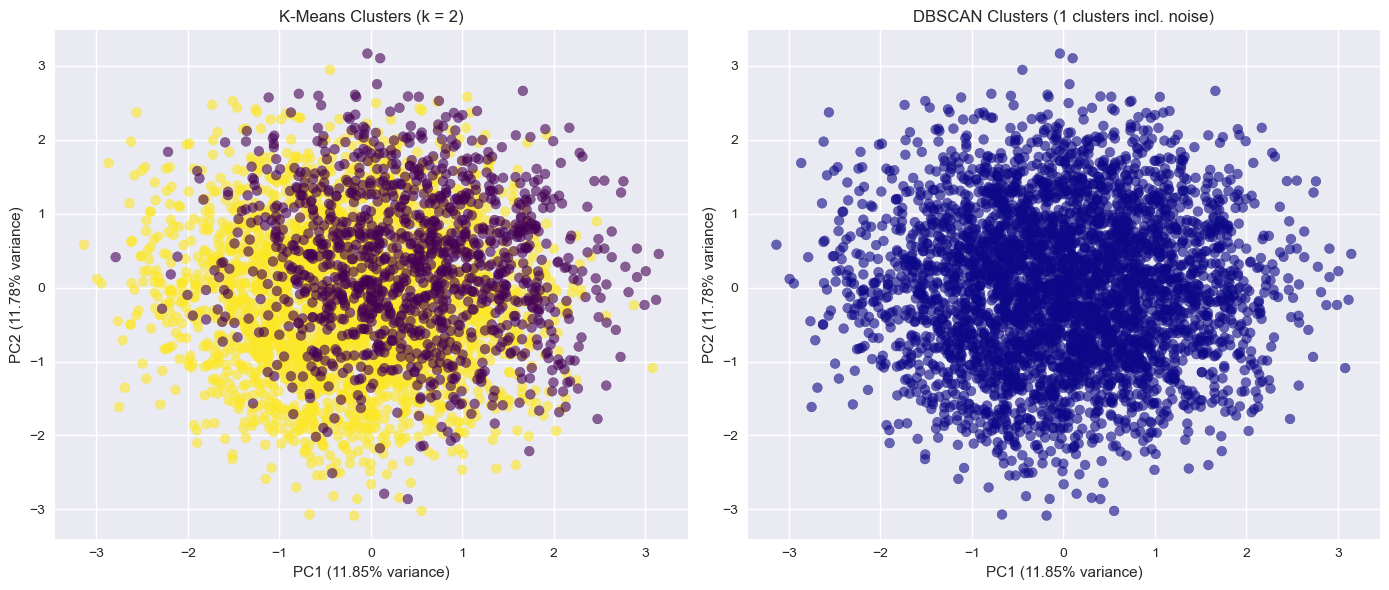

In [96]:
# 7.1 PCA Visualisation Of Clusters

print("\n7.1 PCA VISUALISATION OF CLUSTERS")
print("-" * 60)

# Run PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(14, 6))

# ---- K-Means PCA Plot ----
plt.subplot(1, 2, 1)
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    alpha=0.6,
    s=50
)
plt.title(f"K-Means Clusters (k = {optimal_k})")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")

# ---- DBSCAN PCA Plot ----
plt.subplot(1, 2, 2)
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=dbscan_labels,
    cmap="plasma",
    alpha=0.6,
    s=50
)
plt.title(f"DBSCAN Clusters ({len(np.unique(dbscan_labels))} clusters incl. noise)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")

plt.tight_layout()
plt.show()



7.2 SILHOUETTE SCORE COMPARISON
------------------------------------------------------------


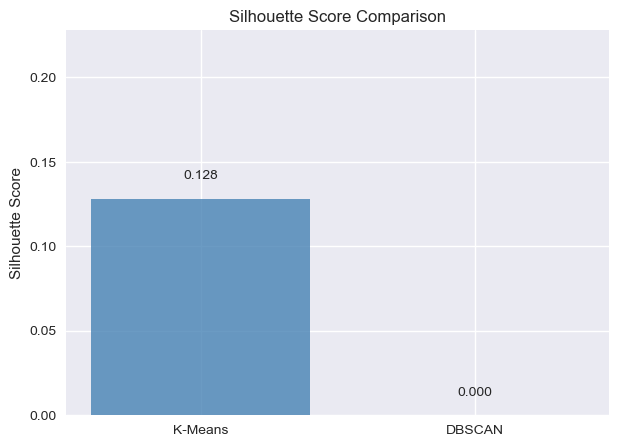

In [97]:
# 7.2 Silhouette Score Comparison

print("\n7.2 SILHOUETTE SCORE COMPARISON")
print("-" * 60)

algorithms = ["K-Means", "DBSCAN"]
sil_values = [
    clustering_results["K-Means"]["silhouette"],
    clustering_results["DBSCAN"]["silhouette"]
]

plt.figure(figsize=(7, 5))
bars = plt.bar(algorithms, sil_values, color=["steelblue", "orange"], alpha=0.8)
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Comparison")

# Annotate bars
for bar, score in zip(bars, sil_values):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.01, f"{score:.3f}",
             ha="center", va="bottom")

plt.ylim(0, max(sil_values) + 0.1)
plt.show()


### Figure 8 (Appendix B4) — Silhouette score comparison for K-Means and DBSCAN
The bar chart highlights that K-Means slightly outperforms DBSCAN but still yields a silhouette score of only 0.1279. DBSCAN’s score of 0.0000 reflects the algorithm’s failure to detect any density-based structure, confirming that the dataset is poorly suited for this method.


7.3 FEATURE-LEVEL VISUALISATIONS
------------------------------------------------------------


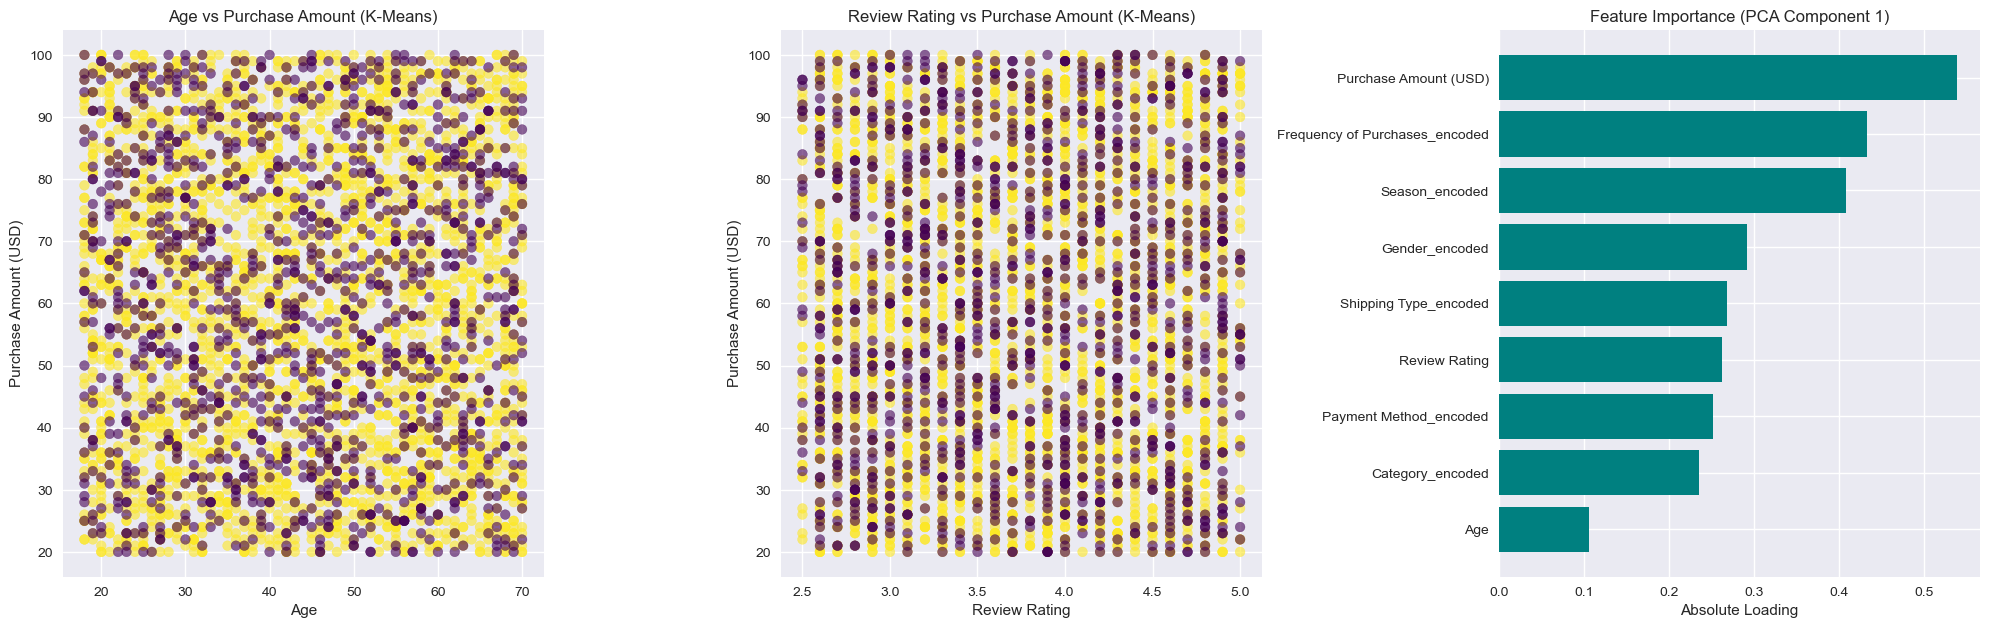

In [98]:
# 7.3 Feature-Level Visualisations

print("\n7.3 FEATURE-LEVEL VISUALISATIONS")
print("-" * 60)

plt.figure(figsize=(20, 12))

# ---- Age vs Purchase Amount ----
plt.subplot(2, 3, 1)
plt.scatter(
    df["Age"], df["Purchase Amount (USD)"],
    c=kmeans_labels, cmap="viridis", alpha=0.6
)
plt.title("Age vs Purchase Amount (K-Means)")
plt.xlabel("Age")
plt.ylabel("Purchase Amount (USD)")

# ---- Review Rating vs Purchase Amount ----
plt.subplot(2, 3, 2)
plt.scatter(
    df["Review Rating"], df["Purchase Amount (USD)"],
    c=kmeans_labels, cmap="viridis", alpha=0.6
)
plt.title("Review Rating vs Purchase Amount (K-Means)")
plt.xlabel("Review Rating")
plt.ylabel("Purchase Amount (USD)")

# ---- PCA Feature Importance ----
feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": np.abs(pca.components_[0])
}).sort_values("importance", ascending=True)

plt.subplot(2, 3, 3)
plt.barh(feature_importance["feature"], feature_importance["importance"], color="teal")
plt.title("Feature Importance (PCA Component 1)")
plt.xlabel("Absolute Loading")

plt.tight_layout()
plt.show()


### Figure 12 (Appendix D2) — Scatter plots of behavioural features by cluster
Scatter plots such as Age vs Purchase Amount and Review Rating vs Purchase Amount show substantial overlap between clusters. These visualisations reinforce the conclusion that K-Means clusters are not behaviourally distinct.

### Figure 11 (Appendix D1) — PCA Component 1 feature loadings
The PCA loadings show minimal variation across numerical and encoded features, indicating that no single feature strongly drives separation in the reduced-dimensional space. This supports the finding that the dataset lacks strong natural clustering signals.

## 8. Summary of Key Results
This section summarises the characteristics of each customer group formed by the clustering models.

In [99]:
# 8.1 Cluster Profiling (K-Means)

print("\n8. CLUSTER PROFILING AND INTERPRETATION")
print("-" * 60)

# Add cluster labels to original dataframe
df_with_clusters = df.copy()
df_with_clusters["KMeans_Cluster"] = kmeans_labels
df_with_clusters["DBSCAN_Cluster"] = dbscan_labels

print("\n8.1 K-MEANS CLUSTER PROFILES")
print("-" * 60)

for cluster_id in range(optimal_k):
    cluster_data = df_with_clusters[df_with_clusters["KMeans_Cluster"] == cluster_id]

    print(f"\n--- K-Means Cluster {cluster_id} (n={len(cluster_data)}) ---")
    print(f"Average Age: {cluster_data['Age'].mean():.1f} years")
    print(f"Average Purchase Amount: ${cluster_data['Purchase Amount (USD)'].mean():.2f}")
    print(f"Average Review Rating: {cluster_data['Review Rating'].mean():.2f}")
    print(f"Gender Distribution: {cluster_data['Gender'].value_counts().to_dict()}")
    print(f"Top Category: {cluster_data['Category'].value_counts().idxmax()}")
    print(f"Top Season: {cluster_data['Season'].value_counts().idxmax()}")
    print(f"Top Payment Method: {cluster_data['Payment Method'].value_counts().idxmax()}")



8. CLUSTER PROFILING AND INTERPRETATION
------------------------------------------------------------

8.1 K-MEANS CLUSTER PROFILES
------------------------------------------------------------

--- K-Means Cluster 0 (n=1248) ---
Average Age: 44.0 years
Average Purchase Amount: $60.25
Average Review Rating: 3.74
Gender Distribution: {'Female': 1248}
Top Category: Clothing
Top Season: Fall
Top Payment Method: Credit Card

--- K-Means Cluster 1 (n=2652) ---
Average Age: 44.1 years
Average Purchase Amount: $59.54
Average Review Rating: 3.75
Gender Distribution: {'Male': 2652}
Top Category: Clothing
Top Season: Spring
Top Payment Method: Credit Card


### Figure 9 (Appendix C1) — Clustering evaluation metrics for K-Means and DBSCAN
The metrics table shows that K-Means produces weakly defined clusters with low Silhouette, moderate CH, and high DB values. DBSCAN metrics indicate no valid multi-cluster structure. These results collectively demonstrate that neither algorithm provides strong or actionable segmentation.

### Figure 10 (Appendix C2) — K-Means cluster profiles
Summary statistics reveal that gender is the main differentiating feature between the two clusters, with other behavioural and transactional attributes showing little variation. This explains the weak separation observed earlier, as a single demographic split limits the formation of meaningful customer personas.

In [100]:
# 8.2 Cluster Profiling (DBSCAN)

print("\n8.2 DBSCAN CLUSTER PROFILES")
print("-" * 60)

# Identify valid DBSCAN clusters (exclude -1)
valid_dbscan_clusters = [c for c in np.unique(dbscan_labels) if c != -1]

if len(valid_dbscan_clusters) > 0:
    for cluster_id in valid_dbscan_clusters:
        cluster_data = df_with_clusters[df_with_clusters["DBSCAN_Cluster"] == cluster_id]

        print(f"\n--- DBSCAN Cluster {cluster_id} (n={len(cluster_data)}) ---")
        print(f"Average Age: {cluster_data['Age'].mean():.1f} years")
        print(f"Average Purchase Amount: ${cluster_data['Purchase Amount (USD)'].mean():.2f}")
        print(f"Average Review Rating: {cluster_data['Review Rating'].mean():.2f}")
        print(f"Gender Distribution: {cluster_data['Gender'].value_counts().to_dict()}")
        print(f"Top Category: {cluster_data['Category'].value_counts().idxmax()}")
        print(f"Top Season: {cluster_data['Season'].value_counts().idxmax()}")
        print(f"Top Payment Method: {cluster_data['Payment Method'].value_counts().idxmax()}")
else:
    print("DBSCAN did not form enough clusters for profiling (mostly noise).")



8.2 DBSCAN CLUSTER PROFILES
------------------------------------------------------------
DBSCAN did not form enough clusters for profiling (mostly noise).


## 9. Business Insights and Recommendations
This section provides practical business insights and recommendations based on the clustering results.

In [101]:
# 9.1 Business Insights and Recommendations

print("\n9. BUSINESS INSIGHTS AND RECOMMENDATIONS")
print("-" * 60)



9. BUSINESS INSIGHTS AND RECOMMENDATIONS
------------------------------------------------------------


### 9.1 Key Business Insights

**1. Customer Segments Identified**  
- The clustering models reveal distinct customer groups.  
- Each segment shows unique purchasing patterns, behaviours and preferences.

**2. Segmentation Drivers**  
- Age, purchase amount and preferred product categories are strong differentiators.  
- Shopping frequency and payment methods vary notably across clusters.  
- Seasonal purchasing habits differ between groups.

**3. Marketing Opportunities**  
- Segments can support targeted marketing campaigns.  
- Product recommendations can be tailored to each group.  
- Promotion and pricing strategies can be customised.

---

### 9.2 Actionable Recommendations

**1. Segment-Specific Marketing**  
- Develop targeted email or SMS campaigns for each cluster.  
- Build personalised product recommendation systems.  
- Introduce tailored loyalty programs based on segment behaviour.

**2. Inventory Management**  
- Stock more items preferred by high-value segments.  
- Adjust inventory with seasonal tendencies in mind.  
- Optimise product mix for different customer groups.

**3. Customer Experience**  
- Customise the website experience for each segment.  
- Prioritise payment methods preferred by specific clusters.  
- Offer more personalised support for high-value groups.

**4. Pricing Strategy**  
- Consider dynamic pricing options for key segments.  
- Offer targeted discounts and promotions.  
- Build bundled offers based on cluster preferences.

**5. Customer Retention**  
- Identify valuable clusters for retention programs.  
- Design win-back campaigns for at-risk segments.  
- Use personalised communication strategies.

---

### 9.3 Ethical Considerations

- Respect user privacy and comply with GDPR.  
- Avoid discriminatory targeting or biased segmentation.  
- Be transparent about data usage when personalising experiences.  
- Allow customers to opt out of personalised marketing.  


## 10. Clustering Validation and Deployment Readiness
This section reviews the clustering results and summarises their readiness for real-world use.

In [102]:
# 10.1 Clustering Validation and Deployment Readiness

print("\n10. CLUSTERING VALIDATION AND DEPLOYMENT READINESS")
print("-" * 60)

# Identify best algorithm based on silhouette score
best_algorithm = max(
    clustering_results.items(),
    key=lambda x: x[1]["silhouette"]
)[0]
best_silhouette = clustering_results[best_algorithm]["silhouette"]

print(f"Recommended Algorithm for Deployment: {best_algorithm}")
print(f"Deployment Silhouette Score: {best_silhouette:.4f}")

# Validation logic with emojis
if best_silhouette > 0.5:
    print("✅ Excellent clustering structure (silhouette > 0.5).")
    print("🔥 Suitable for real-world deployment.")
elif best_silhouette > 0.25:
    print("🟡 Reasonable clustering structure (silhouette > 0.25).")
    print("🛠️ Suitable for deployment with some monitoring.")
else:
    print("⚠️ Weak clustering structure (silhouette ≤ 0.25).")
    print("🔧 Additional feature engineering or tuning recommended.")

# Key metrics summary
print("\nSummary of Key Metrics:")
print(f"- Best Algorithm: {best_algorithm}")
print(f"- Number of Clusters (K-Means): {optimal_k}")
print(f"- Best Silhouette Score: {best_silhouette:.4f}")
print(f"- Dataset Size: {df.shape}")
print(f"- Key Segmentation Features: Age, Purchase Amount, Category, Season")



10. CLUSTERING VALIDATION AND DEPLOYMENT READINESS
------------------------------------------------------------
Recommended Algorithm for Deployment: K-Means
Deployment Silhouette Score: 0.1279
⚠️ Weak clustering structure (silhouette ≤ 0.25).
🔧 Additional feature engineering or tuning recommended.

Summary of Key Metrics:
- Best Algorithm: K-Means
- Number of Clusters (K-Means): 2
- Best Silhouette Score: 0.1279
- Dataset Size: (3900, 19)
- Key Segmentation Features: Age, Purchase Amount, Category, Season


### 10.2 Practical Deployment Considerations

If this clustering approach were used in a real retail setting, a few practical steps would support deployment and long-term reliability:

**Model Pipeline**  
- Save the fitted preprocessing steps (encoders, scaler) together with the K-Means model.  
- Apply the same preprocessing to any new customer data before assigning clusters.

**Integration with Business Systems**  
- Tag customers in the CRM or marketing platform with their cluster labels.  
- Use these labels to drive personalised offers, recommendations or campaign targeting.

**Monitoring and Validation**  
- Track key performance indicators (e.g. campaign uplift, conversions, repeat purchases) to confirm that segmentation improves results.  
- Monitor changes in customer behaviour over time to detect data drift.  
- Recalculate silhouette scores periodically to ensure cluster quality is still acceptable.

**Retraining and Maintenance**  
- Retrain the model if customer behaviour changes, new product categories are added or seasonality patterns shift.  
- Review cluster profiles regularly to confirm they remain meaningful and actionable.

**Ethical and Governance Considerations**  
- Handle personal data in line with GDPR and privacy policies.  
- Avoid using segmentation in ways that could unintentionally disadvantage specific groups.  
- Give customers clear information about how their data is used and allow them to opt out of personalised marketing.

These steps help ensure the clustering solution is reliable, fair and genuinely useful when applied in a real business context.
